<a href="https://colab.research.google.com/github/marcheanin/hf_llm_course/blob/main/11_HF_SFT/Fine_Tune_LLMs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fine-tune LLMs

## Chat Templates

Шаблоны для сообщений нужны в первую очередь для чатботов - они должны соблюдать и понимать принятый формат диалога с LLM.

Chat templates are crucial for:

Maintaining consistent conversation structure

Ensuring proper role identification

Managing context across multiple turns

Supporting advanced features like tool use


### Models types

Обычные модели обучены на предикт следующего токена, а *instruct* модели - для следования инструкциям и поддержания диалога в чатах. При этом такие instruct модели обучекны следовать определенной структуре сообщений, которая делает их подходящими для чат-ботов. При этом некоторые модели обучены взаимодействовать с tools, обрабатывать мультимодальные входы и еще всяким разным интерактивностям.

Чтобы заставить обычную модель работать как instruct, мы должны форматировать наши промпты под специальный формат, который такие модели понимают.

### Common templates formats

Приведу разные примеры темплейтов instruct-моделей

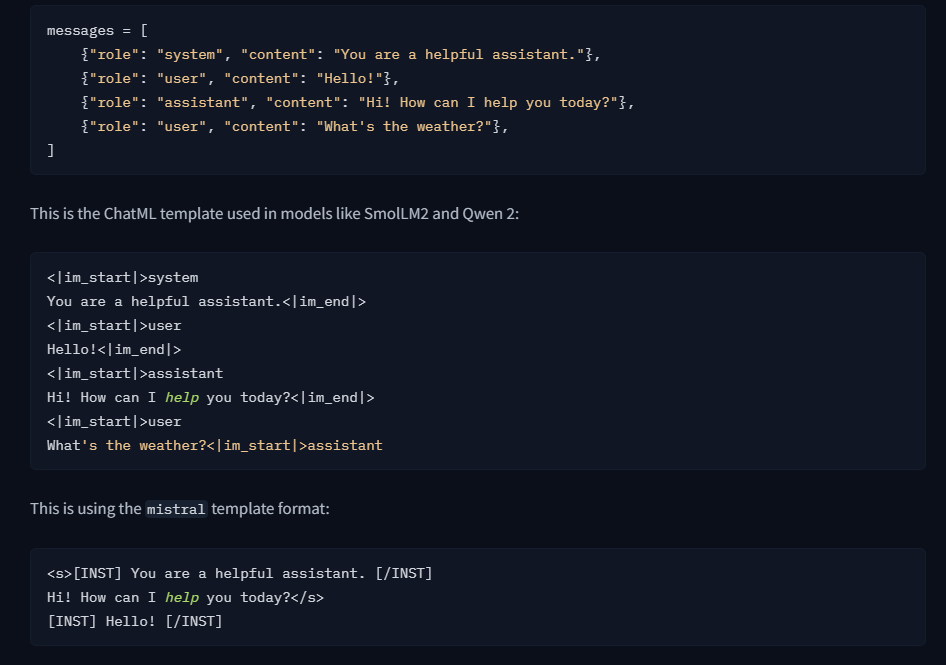

Посмотрим примеры форматирования сообщений для темплейтов разных моделей

In [1]:
from transformers import AutoTokenizer

# These will use different templates automatically
mistral_tokenizer = AutoTokenizer.from_pretrained("mistralai/Mistral-7B-Instruct-v0.1")
# qwen_tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen-7B-Chat", trust_remote_code=True) # Commenting out due to AttributeError
smol_tokenizer = AutoTokenizer.from_pretrained("HuggingFaceTB/SmolLM2-135M-Instruct")

messages = [
    {"role": "system", "content": "You are a helpful assistant."},
    {"role": "user", "content": "Hello!"},
]

# Each will format according to its model's template
mistral_chat = mistral_tokenizer.apply_chat_template(messages, tokenize=False)
# qwen_chat = qwen_tokenizer.apply_chat_template(messages, tokenize=False) # No qwen_tokenizer initialized
smol_chat = smol_tokenizer.apply_chat_template(messages, tokenize=False)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/493k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/861 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/655 [00:00<?, ?B/s]

In [2]:
print("--- Mistral Template ---")
print(mistral_chat)

print("\n--- SmolLM (ChatML) Template ---")
print(smol_chat)

--- Mistral Template ---
<s> [INST] You are a helpful assistant.

Hello! [/INST]

--- SmolLM (ChatML) Template ---
<|im_start|>system
You are a helpful assistant.<|im_end|>
<|im_start|>user
Hello!<|im_end|>



Советы:

- Использовать один и тот же формат на всём приложении
- Обозначать роли каждого сообщения
- Сохраняя историю диалога, учитывать макс токены модели
- Обязательные Error Handlers
- Нужно валидировать корректность сообщений перед отправкой в модель

In [3]:
from datasets import load_dataset

dataset = load_dataset("HuggingFaceTB/smoltalk", "everyday-conversations", split="train")

def convert_to_chatml(example):
    # Проверяем структуру: если колонки 'messages' уже есть, используем их
    if "messages" in example:
        return {"messages": example["messages"]}
    # Иначе создаем из input/output или аналогичных
    return {
        "messages": [
            {"role": "user", "content": example.get("instruction", "")},
            {"role": "assistant", "content": example.get("response", "")},
        ]
    }

sample_data = dataset.select(range(1))
processed_dataset = sample_data.map(convert_to_chatml)

# Применяем шаблон токенизатора SmolLM
sample_messages = processed_dataset[0]["messages"]
formatted_chat = smol_tokenizer.apply_chat_template(sample_messages, tokenize=False)

print("--- Исходные данные (первое сообщение) ---")
print(sample_messages[0]['content'] if len(sample_messages) > 0 else "No content")

print("\n--- Результат в формате ChatML ---")
print(formatted_chat)

README.md: 0.00B [00:00, ?B/s]

data/everyday-conversations/train-00000-(…):   0%|          | 0.00/946k [00:00<?, ?B/s]

data/everyday-conversations/test-00000-o(…):   0%|          | 0.00/52.6k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2260 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/119 [00:00<?, ? examples/s]

Map:   0%|          | 0/1 [00:00<?, ? examples/s]

--- Исходные данные (первое сообщение) ---
Hi there

--- Результат в формате ChatML ---
<|im_start|>system
You are a helpful AI assistant named SmolLM, trained by Hugging Face<|im_end|>
<|im_start|>user
Hi there<|im_end|>
<|im_start|>assistant
Hello! How can I help you today?<|im_end|>
<|im_start|>user
I'm looking for a beach resort for my next vacation. Can you recommend some popular ones?<|im_end|>
<|im_start|>assistant
Some popular beach resorts include Maui in Hawaii, the Maldives, and the Bahamas. They're known for their beautiful beaches and crystal-clear waters.<|im_end|>
<|im_start|>user
That sounds great. Are there any resorts in the Caribbean that are good for families?<|im_end|>
<|im_start|>assistant
Yes, the Turks and Caicos Islands and Barbados are excellent choices for family-friendly resorts in the Caribbean. They offer a range of activities and amenities suitable for all ages.<|im_end|>
<|im_start|>user
Okay, I'll look into those. Thanks for the recommendations!<|im_end

## Fine-tuning with SFT-trainer



Это процесс адаптации модели к следованию инструкциям. После основного обучения, модели обладают широкии спектром экспертизы, SFT этап учит модель применять эти знания и быть полезной. Это происходит путем дообучения на датасете с человеческими диалогами и инструкциями.

### Где использовать SFT

Перед использованием в проекте важно понять, не существует ли уже хорошо подходящей модели для целе, так как процесс SFT - долгий и ресурсозатратный.

Стоит рассматривать SFT если:
- Нужна дополнительная производительность поверх достигнутой
- Легче/дешевле дообучить небольшую модель, нежели использовать большую
- Нужен специфичный выходной формат или специфичные доменные знания

### Доменная адаптация

При работе в специализированных доменах, SFT помогает привести модель в соответствие с доменно-специфическими моментами:

1. Доменно-специфическая терминология и концепты
2. Соблюдение профессиональных стандартов
3. Правильная обработка технических запросов
4. Поддержка специфичкских доменных инструкций

Перед SFT проверить, требует ли конкретный случай:

- Точное форматирование вывода
- Доменно-специфичные знания
- Последовательные действия в некоторых ситуациях
- Соблюдение конкретных принципов

### Подготовка датасета

Нужен датасет специализированного формата, каждая пара в этом датасете должна состоять из:

1. Входного промпта
2. Ожидаемого ответа модели
3. Какой-то контекст/метадата

### Реализация SFT

In [ ]:

from datasets import load_dataset
from trl import SFTConfig, SFTTrainer
import torch

# Set device
device = "cuda" if torch.cuda.is_available() else "cpu"

# Load dataset
dataset = load_dataset("HuggingFaceTB/smoltalk", "all")

In [8]:
!pip install --upgrade trl

In [12]:
from transformers import AutoModelForCausalLM, AutoTokenizer

model_name = "HuggingFaceTB/SmolLM2-135M"
device = "cuda"

model = AutoModelForCausalLM.from_pretrained(model_name).to(device)
tokenizer = AutoTokenizer.from_pretrained(model_name)

special_tokens = ["<|im_start|>", "<|im_end|>"]
tokenizer.add_special_tokens({"additional_special_tokens": special_tokens})

# Set a simple chat template (adjust roles to match your dataset)
tokenizer.chat_template = (
    "{% for message in messages %}"
    "{% if message['role'] == 'system' %}"
    "<|im_start|>system\n{{ message['content'] }}<|im_end|>\n"
    "{% elif message['role'] == 'user' %}"
    "<|im_start|>user\n{{ message['content'] }}<|im_end|>\n"
    "{% elif message['role'] == 'assistant' %}"
    "<|im_start|>assistant\n{{ message['content'] }}<|im_end|>\n"
    "{% endif %}"
    "{% endfor %}"
    "{% if add_generation_prompt %}"
    "<|im_start|>assistant\n"
    "{% endif %}"
)

# Resize model embeddings to accommodate the new tokens
model.resize_token_embeddings(len(tokenizer))

# Now use SFTTrainer as before
from trl import SFTConfig, SFTTrainer

training_args = SFTConfig(
    output_dir="./sft_output",
    max_steps=1000,
    per_device_train_batch_size=32,
    learning_rate=5e-5,
    logging_steps=10,
    save_steps=100,
    eval_strategy="steps",
    eval_steps=50,
    packing=True
)

trainer = SFTTrainer(
    model=model,
    args=training_args,
    train_dataset=dataset["train"],
    eval_dataset=dataset["test"],
    processing_class=tokenizer
)

trainer.train()

Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

Tokenizing train dataset:   0%|          | 0/1043917 [00:00<?, ? examples/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (8567 > 8192). Running this sequence through the model will result in indexing errors


KeyboardInterrupt: 

### Работа с датасетом

SFTrainer поддерживает запаковку примеров для увеличения эффективности обучения на GPU. Это позволяет запаковать несколько небольших примеров и увеличить использование возможностей GPU. Для этого надо указать `packing=True`.

In [ ]:
# Configure packing
training_args = SFTConfig(packing=True)

trainer = SFTTrainer(model=model, train_dataset=dataset, args=training_args)

trainer.train()

Для запаковки датасета с несколькими полями, должны явно определить функцию комбинации таких полей

In [13]:
def formatting_func(example):
    text = f"### Question: {example['question']}\n ### Answer: {example['answer']}"
    return text


training_args = SFTConfig(packing=True)
trainer = SFTTrainer(
    "facebook/opt-350m",
    train_dataset=dataset,
    args=training_args,
    formatting_func=formatting_func,
)

config.json:   0%|          | 0.00/644 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/663M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/388 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/662M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/137 [00:00<?, ?B/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/441 [00:00<?, ?B/s]

Map:   0%|          | 0/1043917 [00:00<?, ? examples/s]

KeyError: 'question'

### После обучения

1. Оценить на test выборке
2. Проверить соблюдение паттернов вывода на нескольких примерах
3. Проверить адаптированность к новому домену
4. Промониторить боевой набор метрик на проде

## LoRA

SFT - ресурсоемкий процесс. LoRA - один из PEFT способов сокращения числа обучаемых параметров без существенных потерь в эффективности обучения.

Вместо всех весов, мы обучаем небольшие метрицы, главным образом влияя на веса сдлев внимания.

Ключевые преимущества:

1. Эффективность по памяти (только адаптеры идут в GPU, веса модели заморожены, позволяет обучать LLM на пользовательских GPU)
2. Фичи обучения (можно нативно интегрировать в существующие модели и обучать существующими библиотеками, поддержка QLora)
3. Чекпоинты для сохранеия весов адаптеров

Теперь загрузим LoRA адаптеры:

Есть библиотека PEFT, которая в том числе содержит все для загрузки и дообучнения LoRA

In [15]:
!pip install --upgrade torchao
from peft import PeftModel, PeftConfig
from transformers import AutoModelForCausalLM

config = PeftConfig.from_pretrained("ybelkada/opt-350m-lora")
model = AutoModelForCausalLM.from_pretrained(config.base_model_name_or_path)
lora_model = PeftModel.from_pretrained(model, "ybelkada/opt-350m-lora")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 29.1 MB/s eta 0:00:00
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0


Loading weights:   0%|          | 0/388 [00:00<?, ?it/s]

adapter_model.safetensors:   0%|          | 0.00/6.30M [00:00<?, ?B/s]

Разберемся с основными параметрами обучнеия

r(rank) - размер low-rank матриц. Обычно между 4-32

lora_alpha - насколько увеличиваются LoRA слои (по сути lr для слоев). Обычно берется 2x от обычных слокв

lora_dropout - вероятность допаута в LoRA слоях, обычно 0.05-0.1. Большие значения помогают избежать переобучения

bias - контролирует обучения сдвигов, есть none, all, lora_only. None лувше для эффективности по памяти

traget_modules - Указывает, к каким модулям модели следует применить LoRA. Можно выбрать «все линейные» или конкретные модули, например «q_proj,v_proj». Чем больше модулей, тем выше адаптивность, но тем больше используется памяти.

In [16]:
from peft import LoraConfig

# r: rank dimension for LoRA update matrices (smaller = more compression)
rank_dimension = 6
# lora_alpha: scaling factor for LoRA layers (higher = stronger adaptation)
lora_alpha = 8
# lora_dropout: dropout probability for LoRA layers (helps prevent overfitting)
lora_dropout = 0.05

peft_config = LoraConfig(
    r=rank_dimension,  # Rank dimension - typically between 4-32
    lora_alpha=lora_alpha,  # LoRA scaling factor - typically 2x rank
    lora_dropout=lora_dropout,  # Dropout probability for LoRA layers
    bias="none",  # Bias type for LoRA. the corresponding biases will be updated during training.
    target_modules="all-linear",  # Which modules to apply LoRA to
    task_type="CAUSAL_LM",  # Task type for model architecture
)

Теперь создадим аналогичный SFTTrainer

In [22]:
from trl import SFTConfig, SFTTrainer

# Define the training arguments
args = SFTConfig(
    output_dir="./sft_lora_output",
    max_steps=100,
    per_device_train_batch_size=4,
    learning_rate=2e-4,
    logging_steps=10,
    save_steps=100,
    packing=True
)

# Create SFTTrainer with LoRA configuration
# The trainer will infer max_seq_length automatically if not provided
trainer = SFTTrainer(
    model=model,
    args=args,
    train_dataset=dataset["train"],
    peft_config=peft_config,
    processing_class=tokenizer
)

/usr/local/lib/python3.12/dist-packages/peft/mapping_func.py:72: UserWarning: You are trying to modify a model with PEFT for a second time. If you want to reload the model with a different config, make sure to call `.unload()` before.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:302: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


Tokenizing train dataset:   0%|          | 0/1043917 [00:00<?, ? examples/s]

KeyboardInterrupt: 

## Merging LoRA Adapters

После обучения надо как-то применить обученные адаптеры к модели, для этого используется слияние. Это создает единую модель с комбинированными весами. При слиянии важно следить за память, так как в этот раз мы грузим всю оригинальную модель и форматом чисел (нвпример, float16).

In [ ]:
import torch
from transformers import AutoModelForCausalLM
from peft import PeftModel

# 1. Load the base model
base_model = AutoModelForCausalLM.from_pretrained(
    "base_model_name", torch_dtype=torch.float16, device_map="auto"
)

# 2. Load the PEFT model with adapter
peft_model = PeftModel.from_pretrained(
    base_model, "path/to/adapter", torch_dtype=torch.float16
)

# 3. Merge adapter weights with base model
merged_model = peft_model.merge_and_unload()